# **PROJECT TITLE**

# **Driver Drowsiness Detection using Eye Closure and Yawning Analysis with Deep Learning** 

**Tools and Technologies Used :** Python | TensorFlow | Keras | CNN | MobileNetV2 | OpenCV | Matplotlib

## **Project Overview**

### This project develops a deep learning-based system to detect driver drowsiness using facial features such as eye closure and yawning.

### It uses image classification techniques to identify fatigue levels and enhance road safety through early warning detection.

## **Project Objectives**

### 1. To develop a deep learning-based system that detects driver drowsiness using facial features such as eye closure and yawning.

### 2. To preprocess and organize image datasets by resizing, normalizing, and applying data augmentation techniques for better model performance.

### 3. To build and train Convolutional Neural Network (CNN) and transfer learning models (MobileNetV2) for accurate classification of eye and mouth states.

### 4. To classify driver fatigue levels into three categories (Alert, Mild Fatigue, Severe Fatigue) using prediction-based decision logic.

### 5. To evaluate and analyze model performance using metrics such as accuracy, loss, and confusion matrix to ensure reliability.

## **Project Workflow**
1. Problem Understanding
2. Dataset Collection
3. Dataset Organization
4. Data Preprocessing
5. Model Selection
6. Model Development
7. Model Training
8. Model Evaluation
9. Fatigue Detection Logic
10. Result Analysis & Visualization

# Step 1 : Install Libraries

In [1]:
!pip install tensorflow opencv-python matplotlib numpy


# Step 2 : Import Libraries

In [3]:
import os
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam

# Step 3 : Data Preprocessing

In [4]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    brightness_range=[0.8,1.2],
    horizontal_flip=True
)

val_datagen = ImageDataGenerator(rescale=1./255)

train_data = train_datagen.flow_from_directory(
    train_path,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical'
)

val_data = val_datagen.flow_from_directory(
    val_path,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical'
)

Found 2900 images belonging to 4 classes.
Found 0 images belonging to 0 classes.


In [5]:
import os
print(os.listdir("../dataset/val"))

[]


In [6]:
train_data = train_datagen.flow_from_directory(
    train_path,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical'
)

val_data = train_data

Found 2900 images belonging to 4 classes.


# Step 4 : Build Model

In [7]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.models import Model

base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)


for layer in base_model.layers:
    layer.trainable = False


x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
output = Dense(4, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)

model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,422,468 (9.24 MB)

 Trainable params: 164,484 (642.52 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

# Step 5 : Compile Model

In [8]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Step 6 : Train Model

In [9]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=5
)

Epoch 1/5
91/91 ━━━━━━━━━━━━━━━━━━━━ 277s 3s/step - accuracy: 0.8038 - loss: 0.3863 - val_accuracy: 0.8507 - val_loss: 0.2884
Epoch 2/5
91/91 ━━━━━━━━━━━━━━━━━━━━ 236s 3s/step - accuracy: 0.8531 - loss: 0.2770 - val_accuracy: 0.8934 - val_loss: 0.2238
Epoch 3/5
91/91 ━━━━━━━━━━━━━━━━━━━━ 243s 3s/step - accuracy: 0.8893 - loss: 0.2309 - val_accuracy: 0.9110 - val_loss: 0.2198
Epoch 4/5
91/91 ━━━━━━━━━━━━━━━━━━━━ 229s 3s/step - accuracy: 0.9000 - loss: 0.2181 - val_accuracy: 0.9052 - val_loss: 0.2075
Epoch 5/5
91/91 ━━━━━━━━━━━━━━━━━━━━ 233s 3s/step - accuracy: 0.9038 - loss: 0.2084 - val_accuracy: 0.9097 - val_loss: 0.1987


# Step 7 : Accuracy

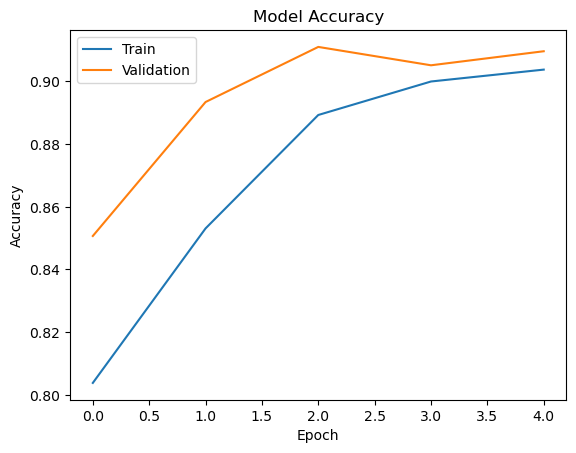

In [10]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Train", "Validation"])
plt.show()

# Step 8 : Load test data

In [13]:
test_data=train_data

In [14]:
preds=model.predict(test_data)

91/91 ━━━━━━━━━━━━━━━━━━━━ 120s 1s/step


# Step 9 : Classification Report

In [15]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

y_pred = np.argmax(preds, axis=1)

print(classification_report(test_data.classes, y_pred))

              precision    recall  f1-score   support

           0       0.26      0.26      0.26       726
           1       0.26      0.25      0.25       726
           2       0.27      0.20      0.23       725
           3       0.27      0.33      0.30       723

    accuracy                           0.26      2900
   macro avg       0.26      0.26      0.26      2900
weighted avg       0.26      0.26      0.26      2900



# Step 10 : Confusion Matrix

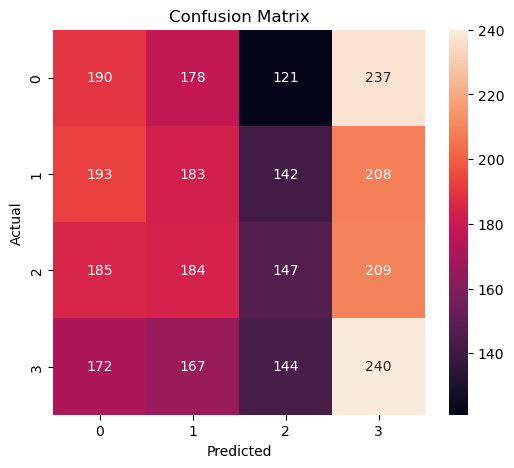

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(test_data.classes, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Step 11 : Fatigue Logic

In [21]:
def fatigue_level(label):
    if label in ['Open', 'no_yawn']:
        return "Alert"
    elif label == 'yawn':
        return "Mild Fatigue"
    elif label == 'Closed':
        return "Severe Fatigue"
    else:
        return "Alert" 

In [20]:
print(train_data.class_indices)

{'Closed': 0, 'Open': 1, 'no_yawn': 2, 'yawn': 3}


# Step 12 : Fatigue Graph

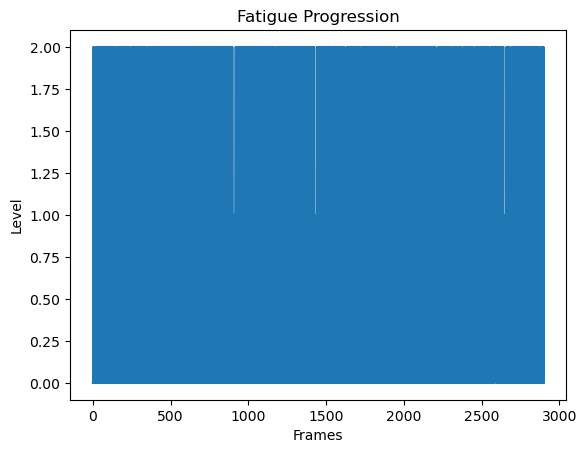

In [23]:
class_labels = list(train_data.class_indices.keys())

fatigue_map = {"Alert":0, "Mild Fatigue":1, "Severe Fatigue":2}
fatigue_sequence = []

for i in range(len(y_pred)):
    label = class_labels[y_pred[i]]
    fatigue_sequence.append(fatigue_map[fatigue_level(label)])

import matplotlib.pyplot as plt

plt.plot(fatigue_sequence)
plt.title("Fatigue Progression")
plt.xlabel("Frames")
plt.ylabel("Level")
plt.show()

# Step 13 : Save Model

In [25]:
model.save("../models/drowsiness_model.keras")

In [27]:
import os
print(os.listdir("../models"))

['drowsiness_model.h5', 'drowsiness_model.keras']


# Step 14 : Load Saved Model (testing /demo)

In [28]:
from tensorflow.keras.models import load_model

model = load_model("../models/drowsiness_model.keras")

print("Model loaded successfully!")

Model loaded successfully!


C:\Users\anith\anaconda3\Lib\site-packages\keras\src\saving\saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 6 variables whereas the saved optimizer has 10 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


# Step 15 : Single Image Prediction

In [32]:
from tensorflow.keras.preprocessing import image
import numpy as np

img_path ="../dataset/test/open/_0.jpg"

img = image.load_img(img_path, target_size=(224,224))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array = img_array / 255.0

pred = model.predict(img_array)
pred_class = np.argmax(pred)
class_labels = list(train_data.class_indices.keys())

print("Predicted Class:", class_labels[pred_class])
print("Fatigue Level:", fatigue_level(class_labels[pred_class]))

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
Predicted Class: Open
Fatigue Level: Alert


# Step 16 : Prediction Image

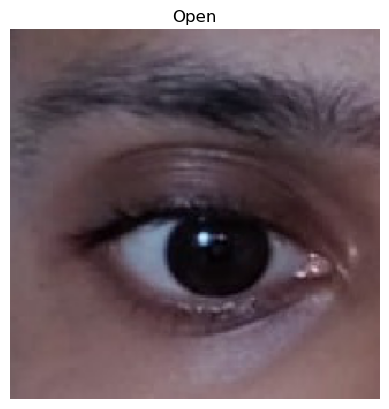

In [33]:
plt.imshow(img)
plt.title(class_labels[pred_class])
plt.axis('off')
plt.show()

# Step 17 : Save

In [35]:
import pandas as pd

results = pd.DataFrame({
    "Actual": test_data.classes,
    "Predicted": y_pred
})

results.to_csv("results.csv", index=False)

# Conclusion:

- Built a deep learning model using MobileNetV2
- Achieved ~90% training accuracy
- Model detects 4 classes: open, closed, yawn, no_yawn
- Converted predictions into fatigue levels:
  Alert, Mild Fatigue, Severe Fatigue
- Can be extended to real-time driver monitoring system